# siebanxico — inicio rápido

Antes de correrlo guarda tu token una sola vez: en la terminal `siebanxico token`, o en Colab como secreto `BANXICO_TOKEN`. Si no lo has hecho, la primera descarga lo pedirá sin mostrarlo.

In [1]:
import siebanxico as sie

sie.catalogo()

,id,descripcion,periodicidad,unidad,agregacion
alias,,,,,
inpc,SP1,"INPC, índice general",Mensual,Índice,ultimo
inpc_subyacente,SP74625,INPC subyacente,Mensual,Índice,ultimo
inpc_no_subyacente,SP74630,INPC no subyacente,Mensual,Índice,ultimo
inflacion_mensual,SP30577,"INPC, variación mensual",Mensual,%,ultimo
inflacion_anual,SP30578,"INPC, variación anual",Mensual,%,ultimo
inflacion_acumulada,SP30579,"INPC, variación acumulada en el año",Mensual,%,ultimo
inflacion_subyacente_anual,SP74662,Inflación subyacente anual,Mensual,%,ultimo
inflacion_no_subyacente_anual,SP74665,Inflación no subyacente anual,Mensual,%,ultimo
inpc_quincenal,SP8664,"INPC quincenal, índice general",Quincenal,Índice,ultimo


## Descarga
Las series diarias y las mensuales se piden por separado y se unen ya en frecuencia mensual.

In [2]:
inpc = sie.serie("inpc", "2000-01-01")
diarias = sie.descargar(["fix", "tasa_objetivo", "cetes_28"], "2000-01-01")

sie.diagnostico(diarias)

,obs,inicio,fin,frecuencia,faltantes,min,max,razon_max_min
serie,,,,,,,,
fix,6736,2000-01-03,2026-10-06,Diaria,2032,8.9428,25.1185,2.808796
tasa_objetivo,6738,2008-01-21,2026-10-06,Diaria,0,3.0000,11.2500,3.750000
cetes_28,1047,2006-09-19,2026-10-06,Semanal,6024,2.4300,11.4000,4.691358


In [3]:
mensual = sie.a_mensual(
    diarias, {"fix": "ultimo", "tasa_objetivo": "promedio", "cetes_28": "promedio"}
)
panel = mensual.join(inpc)
panel.tail()

,fix,tasa_objetivo,cetes_28,inpc
fecha,,,,
2026-06-01,17.4693,6.5,6.2940,145.131
2026-07-01,17.3288,6.5,6.2175,145.169
2026-08-01,17.0147,6.5,6.2125,145.462
2026-09-01,18.0692,6.5,6.2300,NaN
2026-10-01,17.9670,6.5,6.0900,NaN


## Inflación

In [4]:
tabla = sie.inflacion(inpc)
tabla.tail()

,mensual,anual,acumulada,mensual_anualizada
fecha,,,,
2026-04-01,0.197191,4.448503,1.949777,2.392128
2026-05-01,-0.208460,3.938948,1.737252,-2.473043
2026-06-01,-0.272114,3.365977,1.460410,-3.216943
2026-07-01,0.026183,3.117630,1.486976,0.314652
2026-08-01,0.201834,3.261942,1.691811,2.449073


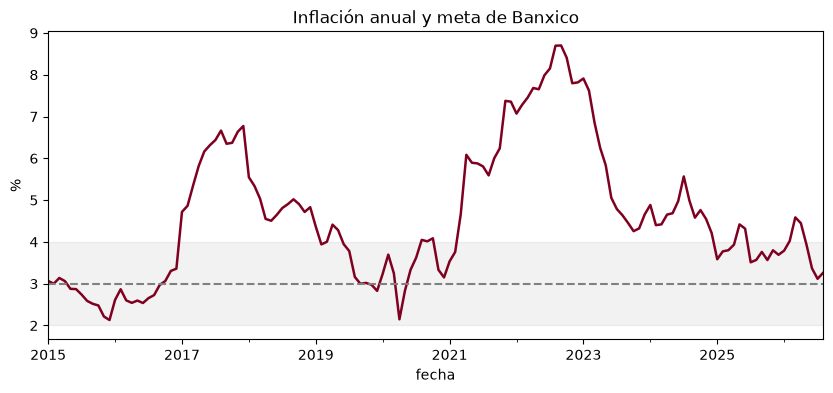

In [5]:
ax = tabla.loc["2015":, "anual"].plot(figsize=(10, 4), color="#800020", lw=1.8)
ax.axhline(3, ls="--", color="gray")
ax.axhspan(2, 4, color="gray", alpha=0.1)
ax.set_title("Inflación anual y meta de Banxico")
ax.set_ylabel("%");

## Poder adquisitivo y tasa real

In [6]:
hoy = inpc.index[-1]
for anio in [2000, 2010, 2020]:
    print(f"$1,000 de enero {anio} = ${sie.a_pesos_de(1000, f'{anio}-01-01', hoy, inpc):,.2f} de {hoy:%b %Y}")

$1,000 de enero 2000 = $3,237.47 de Aug 2026
$1,000 de enero 2010 = $2,004.93 de Aug 2026
$1,000 de enero 2020 = $1,366.52 de Aug 2026


Meses con tasa real negativa: 22.9%


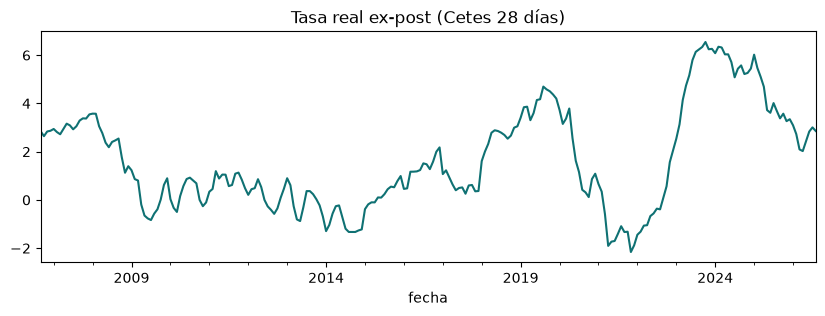

In [7]:
real = sie.tasa_real(panel["cetes_28"], tabla["anual"]).dropna()
print(f"Meses con tasa real negativa: {(real < 0).mean():.1%}")
real.plot(figsize=(10, 3), color="#0F7173", title="Tasa real ex-post (Cetes 28 días)");

## ¿Cuál transformación induce estacionariedad?
Requiere `statsmodels`.

In [8]:
sie.prueba_adf({
    "nivel": inpc,
    "índice base 100": sie.indice_base(inpc, "2018-01-01"),
    "z-score": sie.estandarizar(inpc),
    "Δ ln (inflación mensual)": sie.variacion(inpc, log=True),
    "Δ12 ln (inflación anual)": sie.variacion(inpc, 12, log=True),
})

,estadistico,critico_5%,p_valor,rezagos,obs,estacionaria
serie,,,,,,
nivel,1.903886,-2.871001,0.998534,12,307,False
índice base 100,1.903886,-2.871001,0.998534,12,307,False
z-score,1.903886,-2.871001,0.998534,12,307,False
Δ ln (inflación mensual),-3.654446,-2.871001,0.004801,11,307,True
Δ12 ln (inflación anual),-3.063462,-2.871422,0.029378,13,294,True
